Follow instructions to create an api account on [here](https://developer.spotify.com/documentation/web-api/howtos/web-app-profile)

We are using 
[lychee labs](https://developer.spotify.com/dashboard/de4930a94b4e46599357abca2deadbe9) so no need to create another API account

some intersting things:
- not all podcasts have publishers


Requirements: request, base64, matplotlib, and pandas

In [ ]:
%pip install requests
%pip install matplotlib
%pip install pandas

In [ ]:
import requests
import base64

CLIENT_ID = "de4930a94b4e46599357abca2deadbe9"
CLIENT_SECRET = "ask hannah for secrete key"  # paste your client secret from the Spotify dashboard

# Get access token using Client Credentials flow
def get_access_token(client_id, client_secret):
    auth_string = f"{client_id}:{client_secret}"
    auth_b64 = base64.b64encode(auth_string.encode()).decode()

    resp = requests.post(
        "https://accounts.spotify.com/api/token",
        headers={
            "Authorization": f"Basic {auth_b64}",
            "Content-Type": "application/x-www-form-urlencoded",
        },
        data={"grant_type": "client_credentials"},
    )
    resp.raise_for_status()
    return resp.json()["access_token"]

In [27]:
headers = {"Authorization": f"Bearer {access_token}"}

# Example: Get a show (podcast) by its Spotify ID
# You can find a show's ID from its Spotify URL, e.g.:
# https://open.spotify.com/show/4rOoJ6Egrf8K2IrywzwOMk → ID is "4rOoJ6Egrf8K2IrywzwOMk"
SHOW_ID = "4rOoJ6Egrf8K2IrywzwOMk"  # "The Joe Rogan Experience" as an example

response = requests.get(
    f"https://api.spotify.com/v1/shows/{SHOW_ID}",
    headers=headers,
    params={"market": "US"},
)
response.raise_for_status()
show = response.json()

print(f"Name: {show['name']}")
# print(f"Publisher: {show['publisher']}")
print(f"Description: {show['description'][:200]}") # ueseful for user query
print(f"Total Episodes: {show['total_episodes']}") # useful for user query
print(f"Languages: {show['languages']}") # useful for mandatory filtering
print(f"Explicit: {show['explicit']}") # useful for mandatory filtering
print(f"Spotify URL: {show['external_urls']['spotify']}") # must show
print(show)

Name: The Joe Rogan Experience
Description: The official podcast of comedian Joe Rogan.
Total Episodes: 2652
Languages: ['en']
Explicit: True
Spotify URL: https://open.spotify.com/show/4rOoJ6Egrf8K2IrywzwOMk
{'copyrights': [], 'description': 'The official podcast of comedian Joe Rogan.', 'html_description': '<p>The official podcast of comedian Joe Rogan.</p>', 'explicit': True, 'external_urls': {'spotify': 'https://open.spotify.com/show/4rOoJ6Egrf8K2IrywzwOMk'}, 'href': 'https://api.spotify.com/v1/shows/4rOoJ6Egrf8K2IrywzwOMk?market=US', 'id': '4rOoJ6Egrf8K2IrywzwOMk', 'images': [{'height': 640, 'url': 'https://i.scdn.co/image/ab6765630000ba8aa511819c23efce19751e37f7', 'width': 640}, {'height': 300, 'url': 'https://i.scdn.co/image/ab67656300005f1fa511819c23efce19751e37f7', 'width': 300}, {'height': 64, 'url': 'https://i.scdn.co/image/ab6765630000f68da511819c23efce19751e37f7', 'width': 64}], 'is_externally_hosted': False, 'languages': ['en'], 'media_type': 'mixed', 'name': 'The Joe Roga

In [16]:
# Get episodes for the show
episodes_response = requests.get(
    f"https://api.spotify.com/v1/shows/{SHOW_ID}/episodes",
    headers=headers,
    params={"market": "US", "limit": 10},
)
episodes_response.raise_for_status()
episodes = episodes_response.json()

for i, ep in enumerate(episodes["items"], 1):
    print(f"{i}. {ep['name']}")
    print(f"   Release: {ep['release_date']} | Duration: {ep['duration_ms'] // 60000} min")
    print()

1. #2465 - Michael Shellenberger
   Release: 2026-03-10 | Duration: 177 min

2. JRE MMA Show #175 with Shakur Stevenson
   Release: 2026-03-06 | Duration: 132 min

3. #2464 - Priyanka Chopra Jonas
   Release: 2026-03-05 | Duration: 145 min

4. #2463 - Steve-O
   Release: 2026-03-04 | Duration: 158 min

5. #2462 - Aaron Siri
   Release: 2026-03-03 | Duration: 156 min

6. #2461 - Robert F. Kennedy, Jr.
   Release: 2026-02-27 | Duration: 146 min

7. #2460 - Rachel Wilson
   Release: 2026-02-26 | Duration: 141 min

8. JRE MMA Show #174 with Terence Crawford
   Release: 2026-02-25 | Duration: 130 min

9. #2459 - Jim Breuer
   Release: 2026-02-24 | Duration: 173 min

10. #2458 - Matt McCusker
   Release: 2026-02-20 | Duration: 163 min



In [ ]:
%pip install matplotlib pandas

In [36]:
import pandas as pd
import matplotlib.pyplot as plt
import time
access_token = get_access_token(CLIENT_ID, CLIENT_SECRET)
headers = {"Authorization": f"Bearer {access_token}"}

# Define podcast categories to search
categories = ["comedy", "true crime", "news", "technology", "sports", "health", "education", "music"]

all_shows = []

for category in categories:
    # Search for shows in each category
    search_resp = requests.get(
        "https://api.spotify.com/v1/search",
        headers=headers,
        params={"q": category, "type": "show", "market": "US", "limit": 10},
    )
    search_resp.raise_for_status()
    shows = search_resp.json()["shows"]["items"]

    for s in shows:
        all_shows.append({
            "id": s["id"],
            "name": s["name"],
            "publisher": s["publisher"] if "publisher" in s else "Unknown",
            "total_episodes": s["total_episodes"],
            "category": category,
        })
    time.sleep(0.1)  # small delay to avoid rate limiting

df_shows = pd.DataFrame(all_shows).drop_duplicates(subset="id")
print(f"Collected {len(df_shows)} unique shows across {len(categories)} categories")
df_shows.head(10)

Collected 80 unique shows across 8 categories


,id,name,publisher,total_episodes,category
0,2jrzUni2biU8YxYgRk4CU4,Ridiculous History,Unknown,980,comedy
1,1tnKU0o0aXq2iGHdMy44jm,Comedy Bang Bang: The Podcast,Unknown,160,comedy
2,3gaGfrqgnVqUBNDdtv5p3S,Bad Friends,Unknown,318,comedy
3,77iUVnajPyEWPhY6LxjpzM,KILL TONY,Unknown,758,comedy
4,35Ntc5kndMt5uUCD3RtLhL,Are You Garbage? Comedy Podcast,Unknown,658,comedy
5,6Zo569CigkbLWbgraGVTWP,Just For Laughs - Standup Comedy,Unknown,223,comedy
6,0MkknKUao1N3VbF6Wa3a3v,Spitballers Comedy Podcast,Unknown,643,comedy
7,3N7SfNVU5PcdCvcBf4KMeD,Dave & Chuck the Freak: Full Show,Unknown,227,comedy
8,27n49Gf1onBxr6RwoXqSNP,The Rizzuto Show | Daily Comedy Podcast,Unknown,1780,comedy
9,7pSxCBRcKECVIT2V7OdKT7,4Fun Guys,Unknown,48,comedy


In [41]:
# Fetch episode durations for a sample of shows (first 5 episodes each)
all_episodes = []

for _, row in df_shows.iterrows():
    ep_resp = requests.get(
        f"https://api.spotify.com/v1/shows/{row['id']}/episodes",
        headers=headers,
        params={"market": "US", "limit": 5},
    )
    if ep_resp.status_code != 200:
        continue
    eps = ep_resp.json().get("items", [])
    for ep in eps:
        if ep is None: continue
        all_episodes.append({
            "show_id": row["id"],
            "show_name": row["name"],
            "category": row["category"],
            "episode_name": ep["name"],
            "duration_min": ep["duration_ms"] / 60000,
            "release_date": ep["release_date"],
        })
    time.sleep(0.1)

df_episodes = pd.DataFrame(all_episodes)
print(f"Collected {len(df_episodes)} episodes across {df_episodes['show_id'].nunique()} shows")
df_episodes.head()

Collected 365 episodes across 79 shows


,show_id,show_name,category,episode_name,duration_min,release_date
0,2jrzUni2biU8YxYgRk4CU4,Ridiculous History,comedy,The Spiritualism Movement Was Utterly Ridiculo...,52.606683,2026-03-10
1,2jrzUni2biU8YxYgRk4CU4,Ridiculous History,comedy,"CLASSIC: Idiomatic for the People II, Part I: ...",49.901267,2026-03-07
2,2jrzUni2biU8YxYgRk4CU4,Ridiculous History,comedy,The Spiritualism Movement Was Utterly Ridiculo...,54.200600,2026-03-05
3,2jrzUni2biU8YxYgRk4CU4,Ridiculous History,comedy,History's Weirdest National Anthems,33.913033,2026-03-03
4,2jrzUni2biU8YxYgRk4CU4,Ridiculous History,comedy,CLASSIC: The Statue of Liberty Almost Lived in...,33.895183,2026-02-28


## Distribution of Shows by Number of Episodes

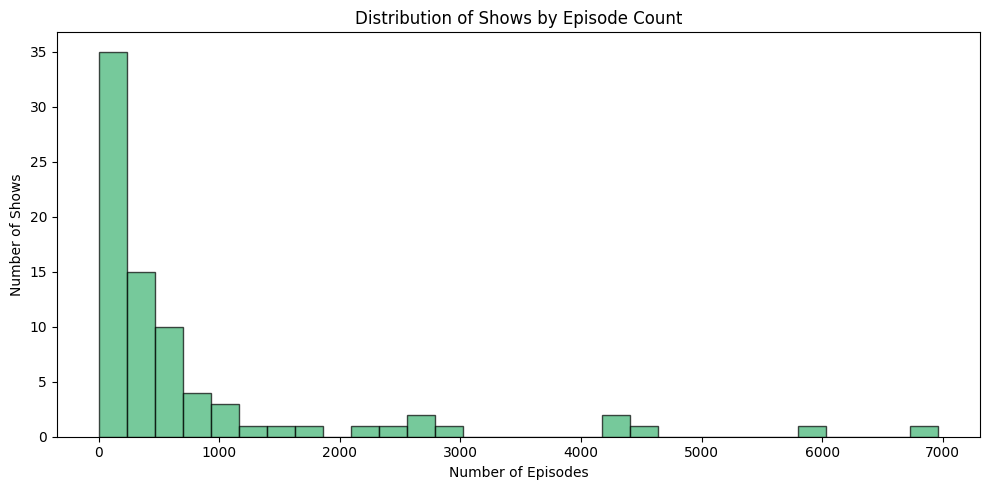

In [42]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(df_shows["total_episodes"], bins=30, edgecolor="black", alpha=0.7, color="mediumseagreen")
ax.set_xlabel("Number of Episodes")
ax.set_ylabel("Number of Shows")
ax.set_title("Distribution of Shows by Episode Count")
plt.tight_layout()
plt.show()

## Distribution of Episode Lengths

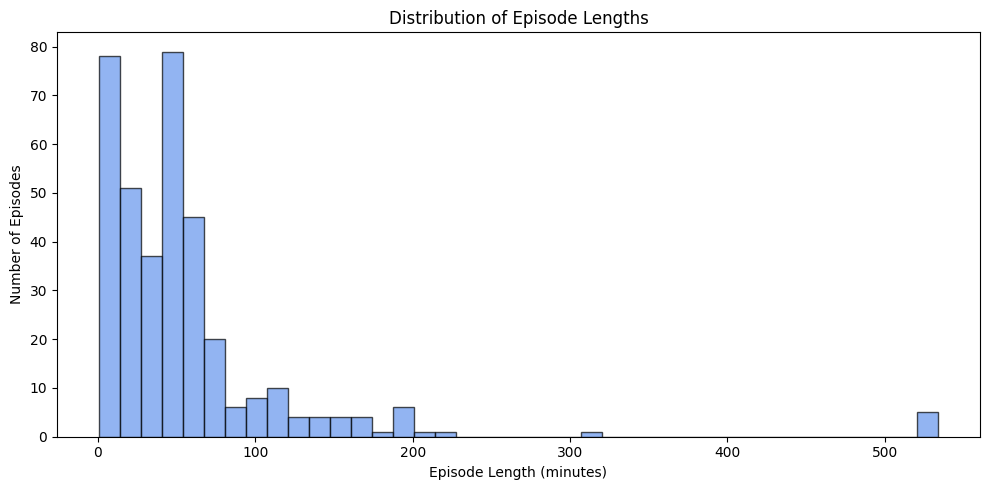

In [43]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(df_episodes["duration_min"], bins=40, edgecolor="black", alpha=0.7, color="cornflowerblue")
ax.set_xlabel("Episode Length (minutes)")
ax.set_ylabel("Number of Episodes")
ax.set_title("Distribution of Episode Lengths")
plt.tight_layout()
plt.show()

## By Category / Genre (Filtering)

C:\Users\hanna\AppData\Local\Temp\ipykernel_19472\4078911404.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(data_by_cat, labels=sorted(categories_in_data))


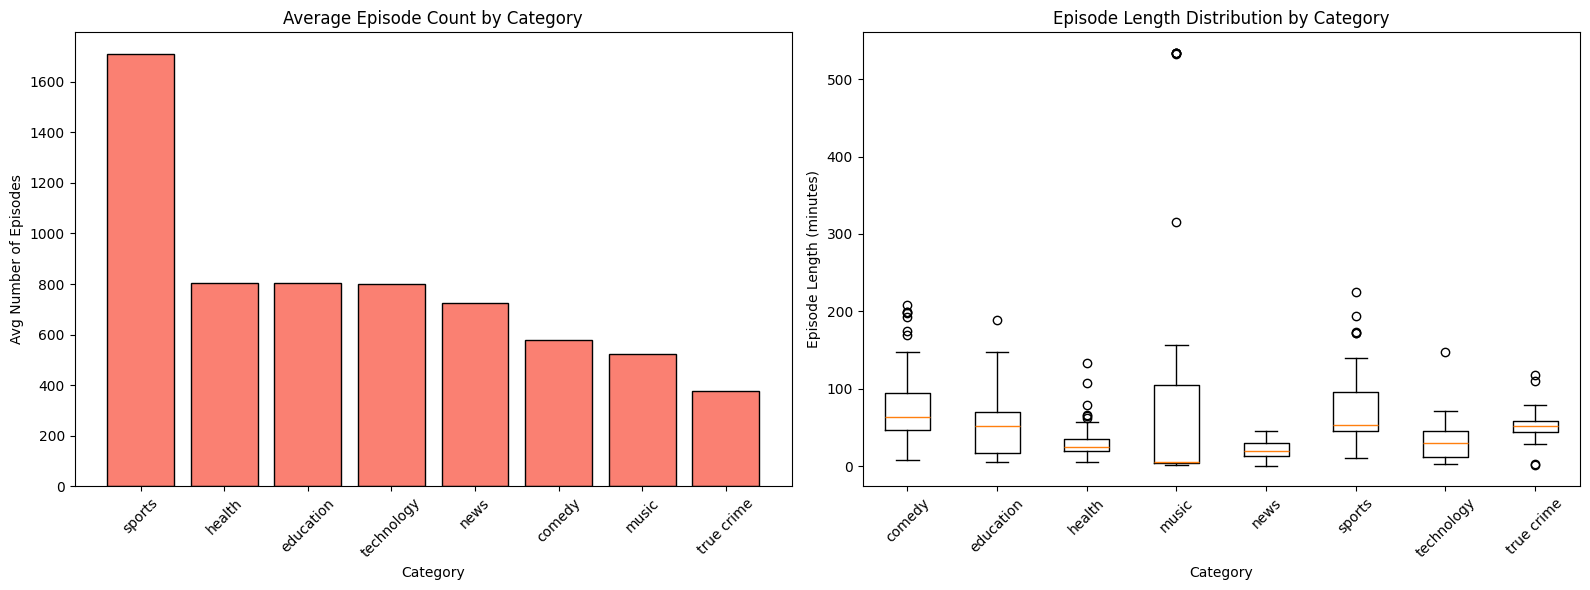

In [44]:
# Average episode count per category
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart: avg episode count by category
cat_avg = df_shows.groupby("category")["total_episodes"].mean().sort_values(ascending=False)
axes[0].bar(cat_avg.index, cat_avg.values, color="salmon", edgecolor="black")
axes[0].set_xlabel("Category")
axes[0].set_ylabel("Avg Number of Episodes")
axes[0].set_title("Average Episode Count by Category")
axes[0].tick_params(axis="x", rotation=45)

# Box plot: episode duration by category
categories_in_data = df_episodes["category"].unique()
data_by_cat = [df_episodes[df_episodes["category"] == c]["duration_min"] for c in sorted(categories_in_data)]
axes[1].boxplot(data_by_cat, labels=sorted(categories_in_data))
axes[1].set_xlabel("Category")
axes[1].set_ylabel("Episode Length (minutes)")
axes[1].set_title("Episode Length Distribution by Category")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

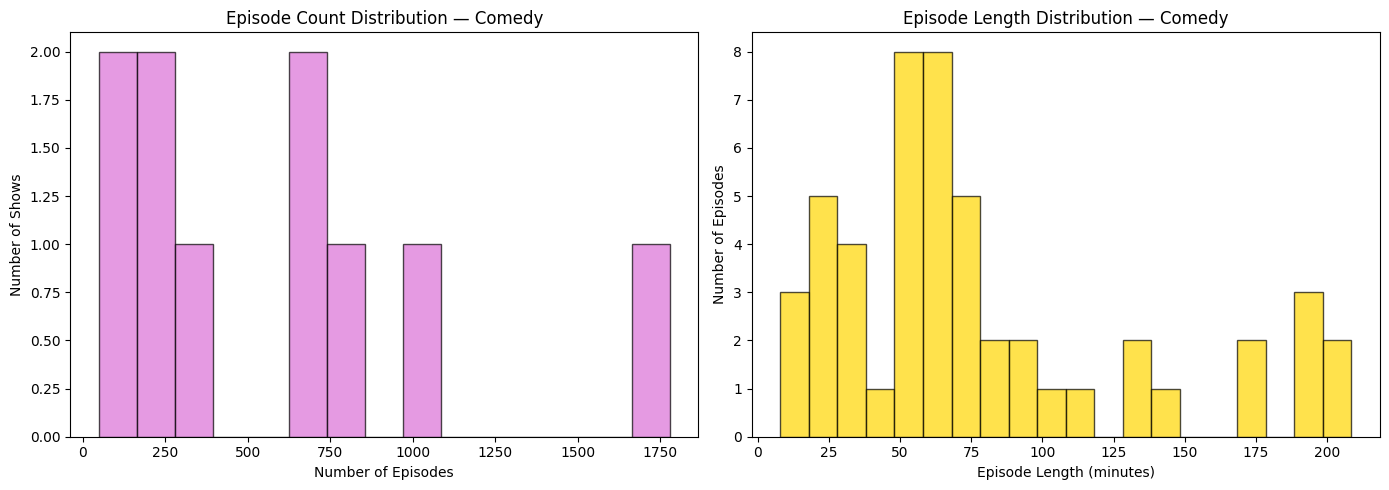


Comedy — 10 shows, 50 episodes sampled
Avg episodes per show: 580
Avg episode length: 78.9 min


In [45]:
# Filter to a specific category and view its data
FILTER_CATEGORY = "comedy"  # change this to any category: "true crime", "news", "technology", etc.

filtered_shows = df_shows[df_shows["category"] == FILTER_CATEGORY]
filtered_episodes = df_episodes[df_episodes["category"] == FILTER_CATEGORY]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(filtered_shows["total_episodes"], bins=15, edgecolor="black", alpha=0.7, color="orchid")
axes[0].set_xlabel("Number of Episodes")
axes[0].set_ylabel("Number of Shows")
axes[0].set_title(f"Episode Count Distribution — {FILTER_CATEGORY.title()}")

axes[1].hist(filtered_episodes["duration_min"], bins=20, edgecolor="black", alpha=0.7, color="gold")
axes[1].set_xlabel("Episode Length (minutes)")
axes[1].set_ylabel("Number of Episodes")
axes[1].set_title(f"Episode Length Distribution — {FILTER_CATEGORY.title()}")

plt.tight_layout()
plt.show()

print(f"\n{FILTER_CATEGORY.title()} — {len(filtered_shows)} shows, {len(filtered_episodes)} episodes sampled")
print(f"Avg episodes per show: {filtered_shows['total_episodes'].mean():.0f}")
print(f"Avg episode length: {filtered_episodes['duration_min'].mean():.1f} min")

In [46]:
# Save data into pickle files
df_shows.to_pickle("spotify_shows.pkl")
df_episodes.to_pickle("spotify_episodes.pkl")